In [1]:
# load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
df = pd.read_csv("Data_Tanaman_Padi_Sumatera_version_1.csv")

In [2]:
# cek missing values
df.isnull().sum()

Provinsi          0
Tahun             0
Produksi          0
Luas Panen        0
Curah hujan       0
Kelembapan        0
Suhu rata-rata    0
dtype: int64

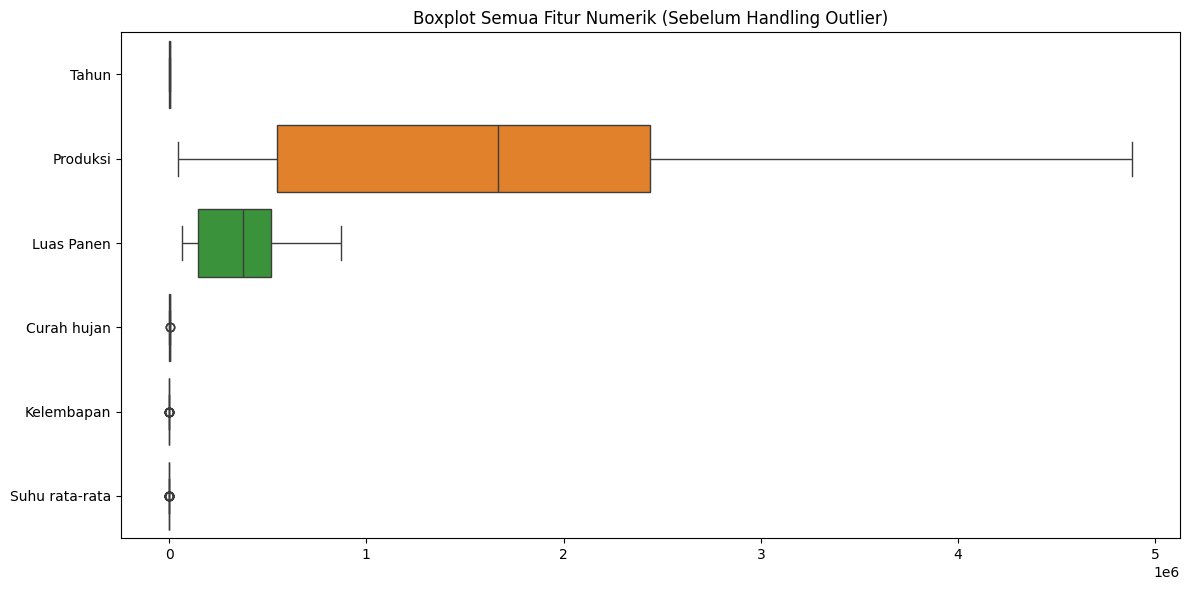

Jumlah outlier per kolom sebelum handling:
Tahun: 0
Produksi: 0
Luas Panen: 0
Curah hujan: 3
Kelembapan: 16
Suhu rata-rata: 28


In [3]:
# Cek outlier 
import numpy as np
import matplotlib.pyplot as plt


# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# 1 Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers 

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


Outlier berhasil di-handle dengan metode capping (clip)


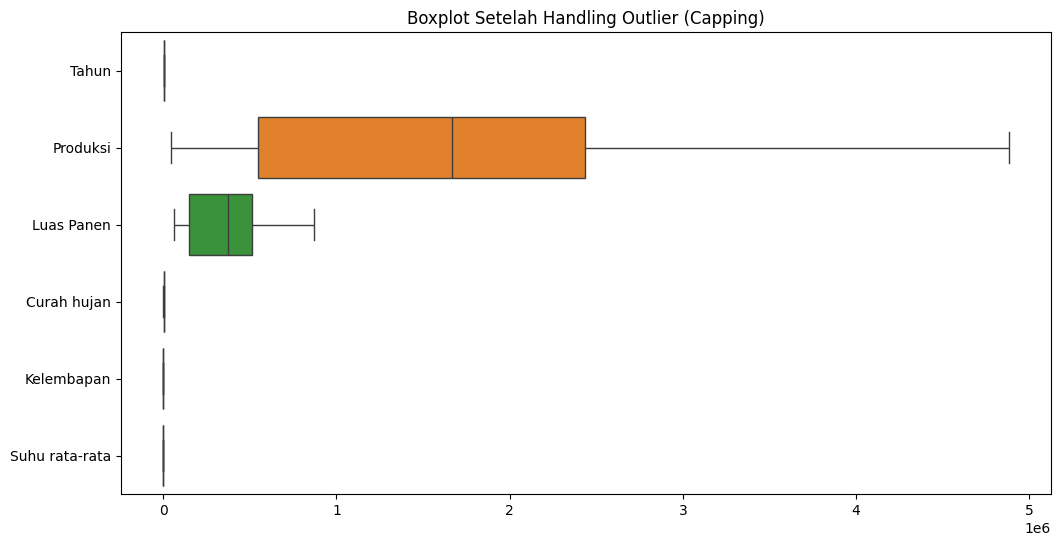

In [4]:
# Loop tiap kolom
for col in num_cols:
    # Hitung Q1, Q3, dan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Tentukan batas bawah & atas
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping (clip)
    df[col] = np.clip(df[col], lower, upper)

print("Outlier berhasil di-handle dengan metode capping (clip)")

# Visualisasi boxplot setelah handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Setelah Handling Outlier (Capping)")
plt.show()


In [5]:
# Dictionary untuk simpan hasil
stats = {}

for col in num_cols:
    data = df[col].dropna().values  # ubah ke numpy array

    stats[col] = {
        'min': np.min(data),
        'max': np.max(data),
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data, ddof=1),   # ddof=1 biar sama kayak pandas
        'var': np.var(data, ddof=1)
    }

# Ubah ke DataFrame biar rapi
stats_np = pd.DataFrame(stats).T

print("Statistik Deskriptif (NumPy):")
print(stats_np)

Statistik Deskriptif (NumPy):
                        min           max          mean       median  \
Tahun            1993.00000  2.020000e+03  2.006500e+03     2006.500   
Produksi        42938.00000  4.881089e+06  1.679701e+06  1667773.000   
Luas Panen      63142.04000  8.727370e+05  3.743500e+05   373551.500   
Curah hujan       222.50000  5.043962e+03  2.449240e+03     2315.700   
Kelembapan         71.43750  9.060000e+01  8.111121e+01       82.375   
Suhu rata-rata     24.64375  2.873375e+01  2.677842e+01       26.730   

                         std           var  
Tahun           8.095838e+00  6.554260e+01  
Produksi        1.161387e+06  1.348821e+12  
Luas Panen      2.327512e+05  5.417310e+10  
Curah hujan     1.023151e+03  1.046838e+06  
Kelembapan      4.377177e+00  1.915968e+01  
Suhu rata-rata  9.970306e-01  9.940700e-01  


In [6]:
# stastika deskriptif tahun
tahun_stats = df['Tahun']
stats_tahun = {
    
    'jumlah_data': len(tahun_stats),
    'min': np.min(tahun_stats),
    'max': np.max(tahun_stats),
    'mean': np.mean(tahun_stats),
    'rentang': np.max(tahun_stats) - np.min(tahun_stats),
    'median': np.median(tahun_stats),
    'std': np.std(tahun_stats, ddof=1),
    'var': np.var(tahun_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Tahun':")
for k, v in stats_tahun.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Tahun':
jumlah_data: 224
min: 1993
max: 2020
mean: 2006.5
rentang: 27
median: 2006.5
std: 8.09583849251336
var: 65.54260089686099


In [7]:
# stastika deskriptif luas panen
luas_panen_stats = df['Luas Panen']
stats_luas_panen = {
    'jumlah_data': len(luas_panen_stats),
    'min': np.min(luas_panen_stats),
    'max': np.max(luas_panen_stats),
    'mean': np.mean(luas_panen_stats),
    'median': np.median(luas_panen_stats),
    'std': np.std(luas_panen_stats, ddof=1),
    'var': np.var(luas_panen_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Luas_Panen':")
for k, v in stats_luas_panen.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Luas_Panen':
jumlah_data: 224
min: 63142.04
max: 872737.0
mean: 374349.9669196429
median: 373551.5
std: 232751.1619874883
var: 54173103406.52602


In [8]:
# stastika deskriptif produksi
produksi_stats = df['Produksi']
stats_produksi = {
    'jumlah_data': len(produksi_stats),
    'min': np.min(produksi_stats),
    'max': np.max(produksi_stats),
    'mean': np.mean(produksi_stats),
    'median': np.median(produksi_stats),
    'std': np.std(produksi_stats, ddof=1),
    'var': np.var(produksi_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Produksi':")
for k, v in stats_produksi.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Produksi':
jumlah_data: 224
min: 42938.0
max: 4881089.0
mean: 1679700.8868303571
median: 1667773.0
std: 1161387.3940689566
var: 1348820679102.282


In [ ]:
# stastika deskriptif 
luas_panen_stats = df['Luas Panen']
stats_luas_panen = {
    'jumlah_data': len(luas_panen_stats),
    'min': np.min(luas_panen_stats),
    'max': np.max(luas_panen_stats),
    'mean': np.mean(luas_panen_stats),
    'median': np.median(luas_panen_stats),
    'std': np.std(luas_panen_stats, ddof=1),
    'var': np.var(luas_panen_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Luas_Panen':")
for k, v in stats_luas_panen.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Luas_Panen':
jumlah_data: 224
min: 63142.04
max: 872737.0
mean: 374349.9669196429
median: 373551.5
std: 232751.1619874883
var: 54173103406.52602


In [10]:
# stastika deskriptif Curah Hujan
curah_hujan_stats = df['Curah hujan']
stats_curah_hujan = {
    'jumlah_data': len(curah_hujan_stats),
    'min': np.min(curah_hujan_stats),
    'max': np.max(curah_hujan_stats),
    'mean': np.mean(curah_hujan_stats),
    'median': np.median(curah_hujan_stats),
    'std': np.std(curah_hujan_stats, ddof=1),
    'var': np.var(curah_hujan_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Curah Hujan':")
for k, v in stats_curah_hujan.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Curah Hujan':
jumlah_data: 224
min: 222.5
max: 5043.9625
mean: 2449.240256696429
median: 2315.7
std: 1023.1510037374234
var: 1046837.9764488968


In [11]:
# stastika deskriptif Kelembapan
kelembapan_stats = df['Kelembapan']
stats_kelembapan = {
    'jumlah_data': len(kelembapan_stats),
    'min': np.min(kelembapan_stats),
    'max': np.max(kelembapan_stats),
    'mean': np.mean(kelembapan_stats),
    'median': np.median(kelembapan_stats),
    'std': np.std(kelembapan_stats, ddof=1),
    'var': np.var(kelembapan_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Kelembapan':")
for k, v in stats_kelembapan.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'Kelembapan':
jumlah_data: 224
min: 71.43749999999999
max: 90.6
mean: 81.11120535714285
median: 82.375
std: 4.37717698536703
var: 19.1596783612268


In [12]:
# stastika deskriptif Suhu rata-rata
suhu_rata_stats = df['Suhu rata-rata']
stats_suhu_rata = {
    'jumlah_data': len(suhu_rata_stats),
    'min': np.min(suhu_rata_stats),
    'max': np.max(suhu_rata_stats),
    'mean': np.mean(suhu_rata_stats),
    'median': np.median(suhu_rata_stats),
    'std': np.std(suhu_rata_stats, ddof=1),
    'var': np.var(suhu_rata_stats, ddof=1)
}
print("\nStatistik Deskriptif untuk kolom 'Suhu rata-rata':")
for k, v in stats_suhu_rata.items():
    print(f"{k}: {v}")



Statistik Deskriptif untuk kolom 'Suhu rata-rata':
jumlah_data: 224
min: 24.643750000000004
max: 28.733749999999993
mean: 26.77841517857143
median: 26.73
std: 0.9970305826219039
var: 0.9940699826833731


    Tahun         max          sum          mean
0    1993  2918152.00  10511106.00  1.313888e+06
1    1994  3079960.00  10434879.00  1.304360e+06
2    1995  3134533.00  11277878.00  1.409735e+06
3    1996  3136760.00  11681931.00  1.460241e+06
4    1997  3212208.00  11069582.00  1.383698e+06
5    1998  3321049.00  11736390.00  1.467049e+06
6    1999  3451430.00  11816051.00  1.477006e+06
7    2000  3514253.00  11901379.00  1.487672e+06
8    2001  3291515.00  11571056.00  1.446382e+06
9    2002  3153305.00  11531731.00  1.441466e+06
10   2003  3403075.00  11823024.00  1.477878e+06
11   2004  3418782.00  12445839.00  1.555730e+06
12   2005  3447394.00  12655694.00  1.581962e+06
13   2006  3007636.00  12001280.00  1.500160e+06
14   2007  3265834.00  12841479.00  1.605185e+06
15   2008  3340794.00  13581940.00  1.697742e+06
16   2009  3527899.00  14652674.00  1.831584e+06
17   2010  3582302.00  15382976.00  1.922872e+06
18   2011  3607403.00  15670413.00  1.958802e+06
19   2012  3715514.0

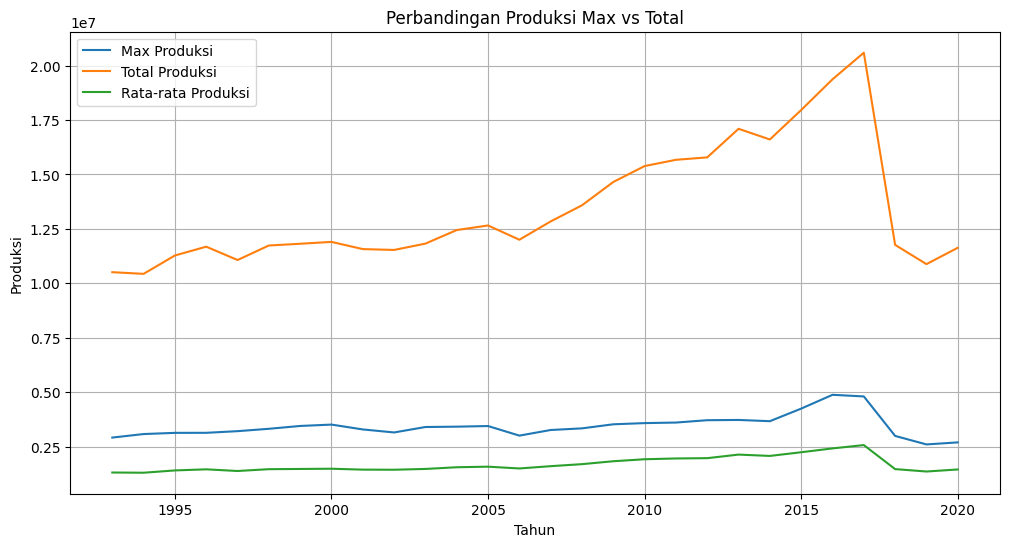

In [ ]:
data_compare = df.groupby('Tahun')['Produksi'].agg(['max', 'sum', 'mean']).reset_index()
print(data_compare)

plt.figure(figsize=(12,6))

sns.lineplot(data=data_compare, x='Tahun', y='max', label='Max Produksi')
sns.lineplot(data=data_compare, x='Tahun', y='sum', label='Total Produksi')
sns.lineplot(data=data_compare, x='Tahun', y='mean', label='Rata-rata Produksi')
plt.xlabel("Tahun")
plt.ylabel("Produksi")

plt.title("Perbandingan Produksi Jumlah Terbanyak vs Rata-rata vs Total")
plt.grid()
plt.show()

           Provinsi     Produksi
7    Sumatera Utara  93253194.72
6  Sumatera Selatan  74161992.54
3           Lampung  68433897.53
5    Sumatera Barat  55731075.23
0              Aceh  45324629.64
2             Jambi  15480186.69
1          Bengkulu  12459015.75
4              Riau  11409006.55


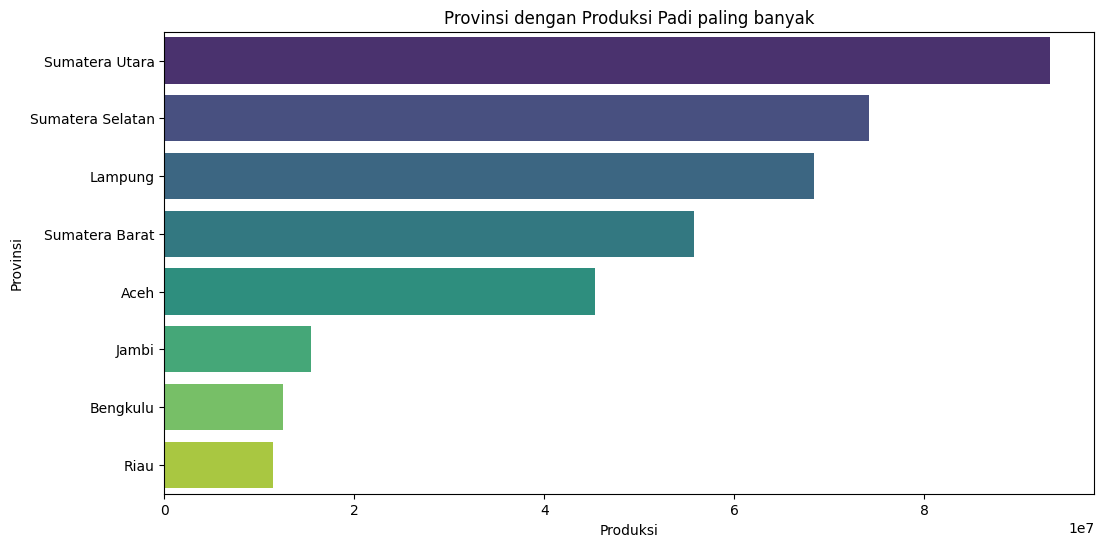

In [14]:
# cek provinsi dengan produksi tertinggi (sum) dengan diagram batang
max_produksi = df.groupby('Provinsi')['Produksi'].sum().reset_index()
max_produksi = max_produksi.sort_values(by='Produksi', ascending=False)
print(max_produksi.head(10))

plt.figure(figsize=(12,6))
sns.barplot(data=max_produksi.head(10), x='Produksi', y='Provinsi', hue='Provinsi', palette='viridis')
plt.title("Provinsi dengan Produksi Padi paling banyak")
plt.xlabel("Produksi")
plt.ylabel("Provinsi")
plt.show()

           Provinsi      Produksi
7    Sumatera Utara  3.330471e+06
6  Sumatera Selatan  2.648643e+06
3           Lampung  2.444068e+06
5    Sumatera Barat  1.990396e+06
0              Aceh  1.618737e+06
2             Jambi  5.528638e+05
1          Bengkulu  4.449648e+05
4              Riau  4.074645e+05


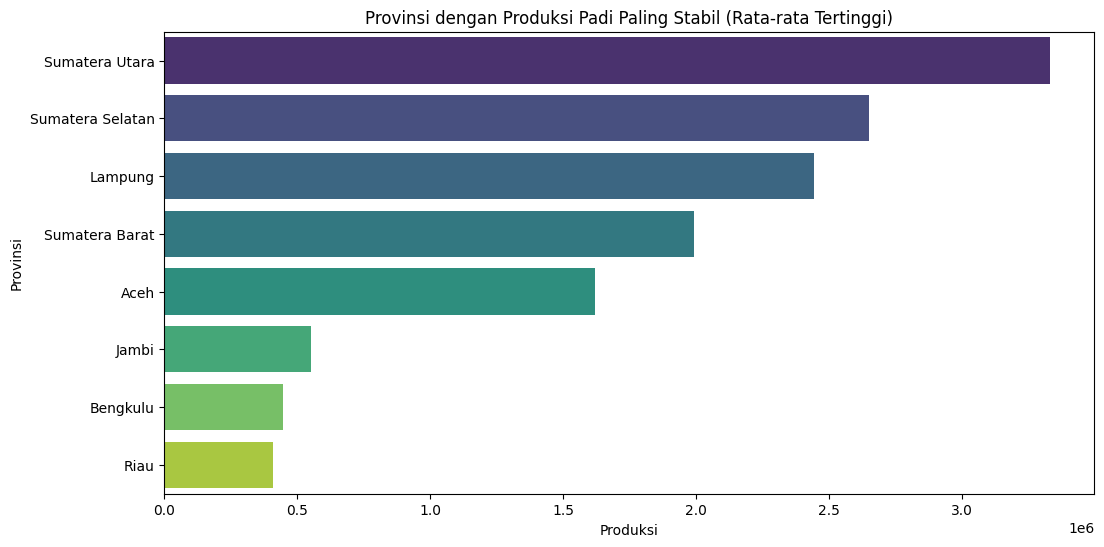

In [15]:
# cek provinsi dengan produksi paling stabil (mean) dengan diagram batang
max_produksi = df.groupby('Provinsi')['Produksi'].mean().reset_index()
max_produksi = max_produksi.sort_values(by='Produksi', ascending=False)
print(max_produksi.head(10))

plt.figure(figsize=(12,6))
sns.barplot(data=max_produksi.head(10), x='Produksi', y='Provinsi', hue='Provinsi', palette='viridis')
plt.title("Provinsi dengan Produksi Padi Paling Stabil (Rata-rata Tertinggi)")
plt.xlabel("Produksi")
plt.ylabel("Provinsi")
plt.show()

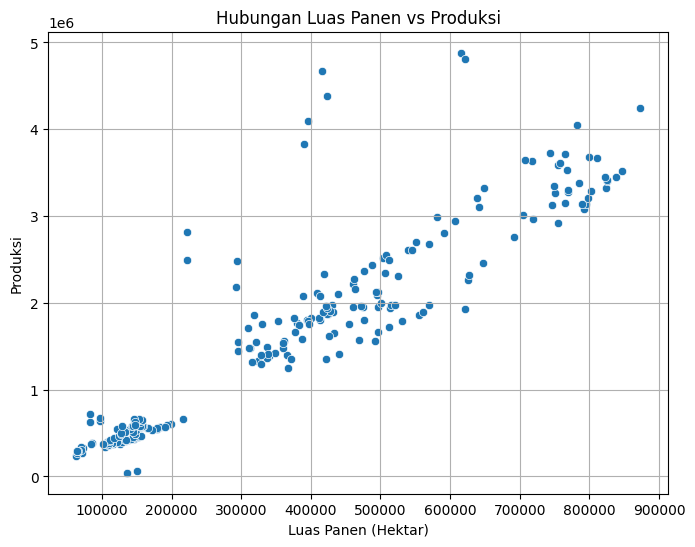

In [16]:
# cek hubungan antara luas panen dengan produksi dengan diagram scatter
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Luas Panen', y='Produksi')
plt.title("Hubungan Luas Panen vs Produksi")
plt.xlabel("Luas Panen (Hektar)")
plt.ylabel("Produksi")
plt.grid()
plt.show()

             Provinsi  Tahun   Produksi  Luas Panen  Efisiensi
80     Sumatera Barat   2017  2810425.0    222021.0  12.658375
52     Sumatera Utara   2017  4669777.5    415675.0  11.234203
79     Sumatera Barat   2016  2487929.0    222482.0  11.182608
51     Sumatera Utara   2016  4387035.9    423029.0  10.370532
220           Lampung   2017  4090654.0    396559.0  10.315373
219           Lampung   2016  3831923.0    390799.0   9.805355
192          Bengkulu   2017   714017.0     82429.0   8.662206
24               Aceh   2017  2478922.0    294483.0   8.417878
163  Sumatera Selatan   2016  4881089.0    615184.0   7.934356
164  Sumatera Selatan   2017  4807430.0    621903.0   7.730193


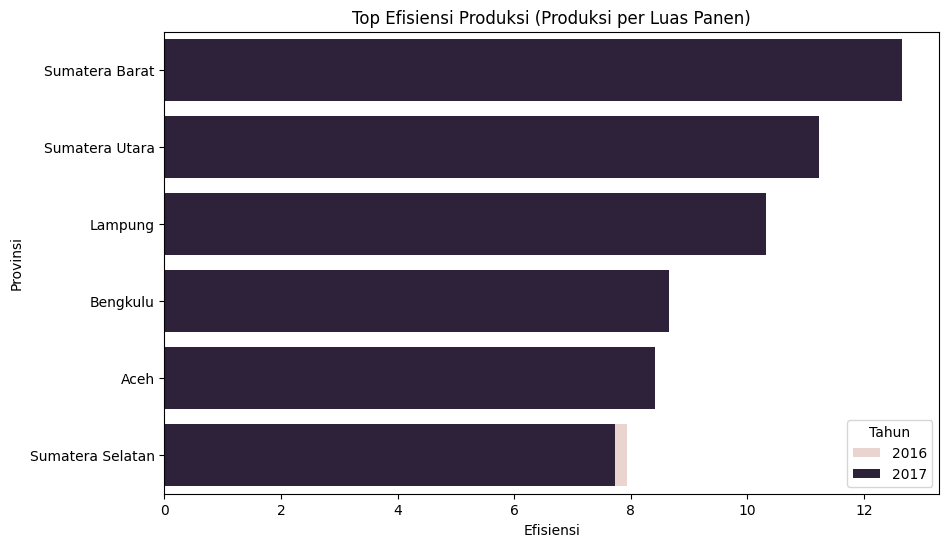

In [17]:
# buat kolom efisiensi
df['Efisiensi'] = df['Produksi'] / df['Luas Panen']

# ambil yang paling efisien
top_efisien = df.sort_values(by='Efisiensi', ascending=False)

# tampilkan top 10
print(top_efisien[['Provinsi', 'Tahun', 'Produksi', 'Luas Panen', 'Efisiensi']].head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_efisien.head(10),
    x='Efisiensi',
    y='Provinsi',
    hue='Tahun',
    dodge=False
)
plt.title("Top Efisiensi Produksi (Produksi per Luas Panen)")
plt.show()

In [ ]:
# buat kolom baru untuk kategori curah hujan
mean = df['Curah hujan'].mean()
std = df['Curah hujan'].std()

def kategori_curah_hujan(x):
    if x < (mean - std):
        return 'Rendah'
    elif x <= (mean + std):
        return 'Sedang'
    else:
        return 'Tinggi'

df['Kategori Curah Hujan'] = df['Curah hujan'].apply(kategori_curah_hujan)

np.int64(224)

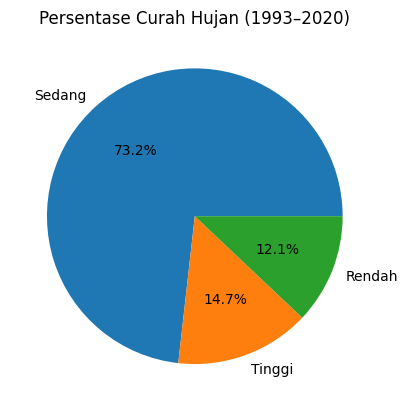

In [ ]:
# cek data dari 1993-2020 presentase curah hujan yang sudah di buat kategori

kategori_counts = df['Kategori Curah Hujan'].value_counts()

plt.figure()
plt.pie(kategori_counts, labels=kategori_counts.index, autopct='%1.1f%%')
plt.title('Persentase Curah Hujan (1993–2020)')
plt.show()



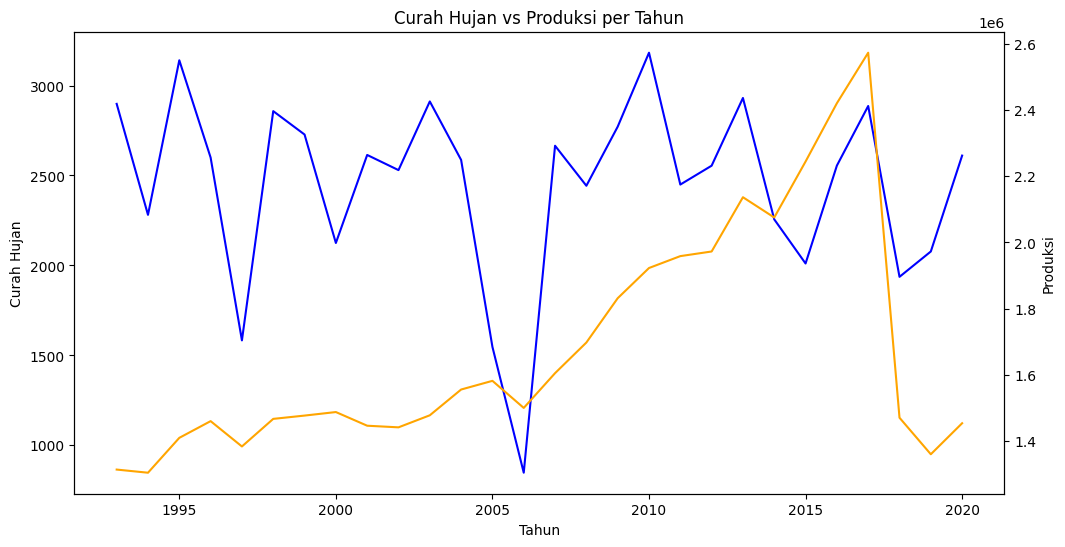

In [26]:
# hubungan antara curah hujan dengan produksi dalam tahun
data_tahun = df.groupby('Tahun')[['Curah hujan', 'Produksi']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

sns.lineplot(data=data_tahun, x='Tahun', y='Curah hujan', ax=ax1, color='blue')
sns.lineplot(data=data_tahun, x='Tahun', y='Produksi', ax=ax2, color='orange')

ax1.set_ylabel('Curah Hujan')
ax2.set_ylabel('Produksi')

plt.title("Curah Hujan vs Produksi per Tahun")
plt.show()
plt.show()

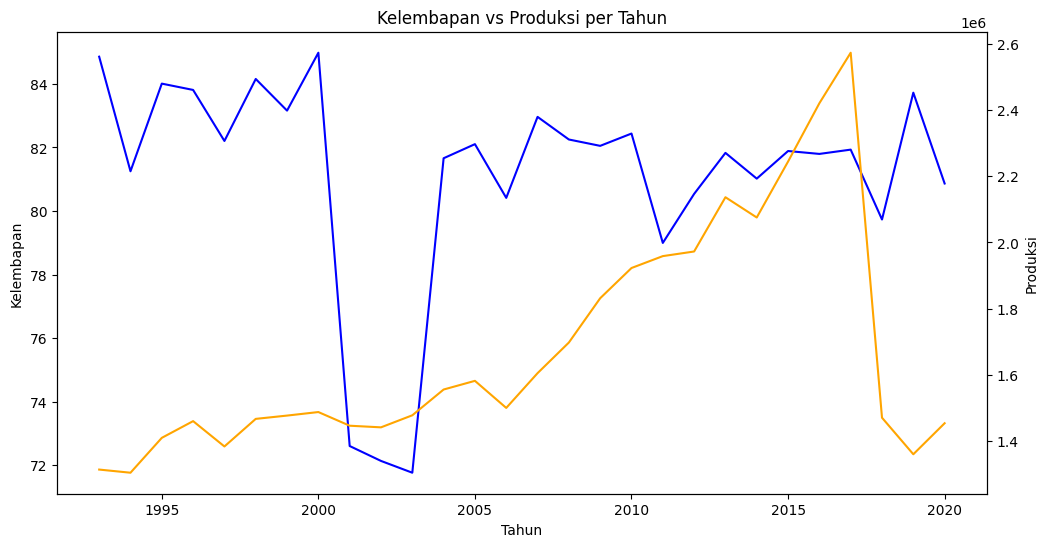

In [ ]:
# hubungan antara Kelembapan dengan produksi
data_tahun = df.groupby('Tahun')[['Kelembapan', 'Produksi']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

sns.lineplot(data=data_tahun, x='Tahun', y='Kelembapan', ax=ax1, color='blue')
sns.lineplot(data=data_tahun, x='Tahun', y='Produksi', ax=ax2, color='orange')

ax1.set_ylabel('Kelembapan')
ax2.set_ylabel('Produksi')

plt.title("Kelembapan vs Produksi per Tahun")
plt.show()
plt.show()

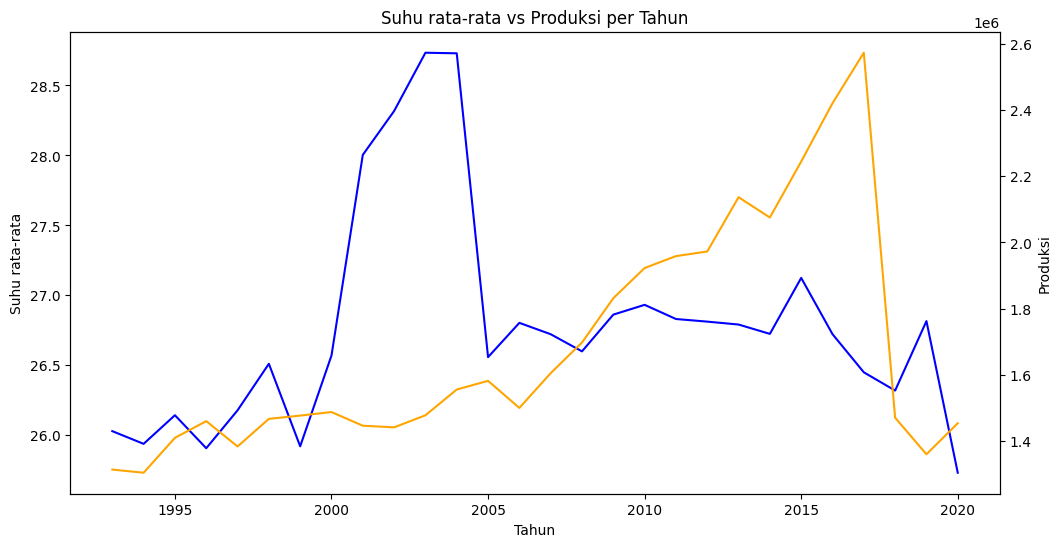

In [31]:
# hubungan antara Suhu rata-rata dengan produksi
data_tahun = df.groupby('Tahun')[['Suhu rata-rata', 'Produksi']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

sns.lineplot(data=data_tahun, x='Tahun', y='Suhu rata-rata', ax=ax1, color='blue')
sns.lineplot(data=data_tahun, x='Tahun', y='Produksi', ax=ax2, color='orange')

ax1.set_ylabel('Suhu rata-rata')
ax2.set_ylabel('Produksi')

plt.title("Suhu rata-rata vs Produksi per Tahun")
plt.show()
plt.show()

In [32]:
print(df[['Curah hujan','Kelembapan','Suhu rata-rata','Produksi']].corr())

                Curah hujan  Kelembapan  Suhu rata-rata  Produksi
Curah hujan        1.000000    0.098461       -0.224848 -0.043123
Kelembapan         0.098461    1.000000       -0.475850 -0.057693
Suhu rata-rata    -0.224848   -0.475850        1.000000  0.077263
Produksi          -0.043123   -0.057693        0.077263  1.000000


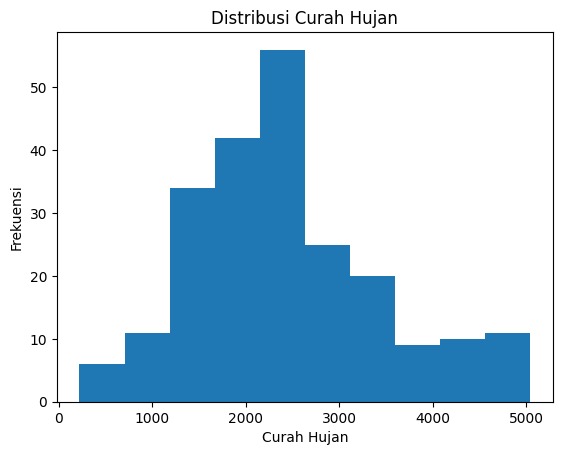

In [33]:
plt.figure()
plt.hist(df['Curah hujan'], bins=10)
plt.title('Distribusi Curah Hujan')
plt.xlabel('Curah Hujan')
plt.ylabel('Frekuensi')
plt.show()

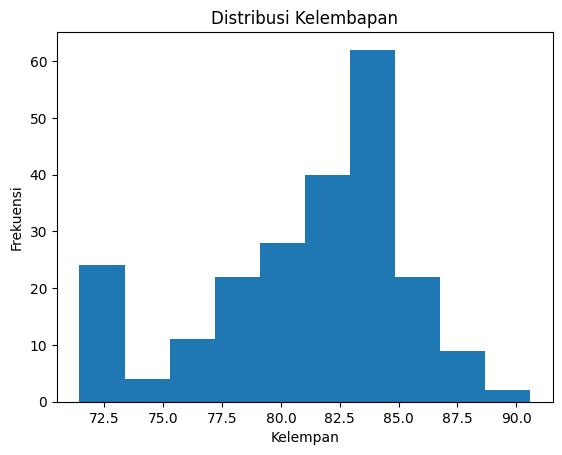

In [ ]:
plt.figure()
plt.hist(df['Kelembapan'], bins=10)
plt.title('Distribusi Kelembapan')
plt.xlabel('Kelembapan')
plt.ylabel('Frekuensi')
plt.show()